In [40]:
import glob
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

import os
while not os.path.isdir('.git'):
    os.chdir('../..')

import matplotlib as mpl
mpl.rcParams["font.family"] = "Avenir"

fig_width = 11.27

In [41]:
test_stimulus_1 = 100
test_stimulus_2 = 2500

ltp_frequency = 50
ltp_start = 1000
ltp_duration = 1000

time_before = 50
time_after = 100

In [42]:
idxs = np.arange(0, 20)

# Figure Results 3

In [26]:
def read_weights(carrier = 1000, offset = 5, strength = 0.9, initial_weight = 0.1):
    if carrier is None:
        filename = f"noTI_{initial_weight}"
    else:
        filename = f"{carrier}_{offset}_{strength}_{initial_weight}"
    
    synapses = [f"Synapse{i}" for i in range(10)]
    weights = []
    time = []
    for idx in idxs:
        weights_idx = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/{filename}/synapse_weights.csv", index_col = 0)
    
        for synapse in synapses:
            weights.append(weights_idx[synapse])
        
        time = weights_idx.Time
    
    weights = np.vstack(weights)
    
    return time, weights

In [27]:
initial_weight = 0.1
carrier = 1000

time_no_ti, weights_no_ti = read_weights(carrier = None, initial_weight = initial_weight)
time_5, weights_5 = read_weights(carrier = carrier, offset = 5, strength = 0.9, initial_weight = initial_weight)
time_130, weights_130 = read_weights(carrier = carrier, offset = 130, strength = 0.9, initial_weight = initial_weight)
time_0, weights_0 = read_weights(carrier = carrier, offset = 0, strength = 0.1, initial_weight = initial_weight)

In [28]:
final_weights = {
    "No TI": [],
    "5 Hz TI": [],
    "130 Hz TI": [],
    "0 Hz TI": []
}

for condition, weight, time in zip(
        final_weights.keys(),
        [weights_no_ti, weights_5, weights_130, weights_0],
        [time_no_ti, time_5, time_130, time_0]
):
    time_idx = np.where(time > ltp_start + ltp_duration + 100)[0][0]
    final_weights[condition] = weight[:, time_idx]

In [29]:
def match_array_size(*arrays):
    min_len = min(arr.shape[0] for arr in arrays)
    return [arr[:min_len] for arr in arrays]

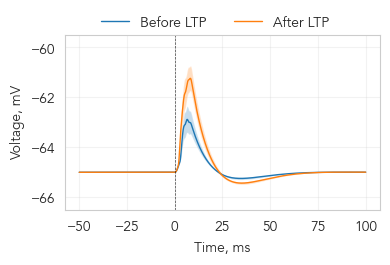

In [30]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 2.5))
ax = axs

epsp_before = []
epsp_after = []

time = []

for idx in idxs:
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/noTI_0.1/voltage.csv")

    time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
    epsp_before_idx = np.array(voltage.Voltage[time_epsp_before].tolist())
    epsp_before.append(epsp_before_idx)

    time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    epsp_after_idx = np.array(voltage.Voltage[time_epsp_after].tolist())
    epsp_after.append(epsp_after_idx)

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
    time, epsp_before_idx, epsp_after_idx = match_array_size(time, epsp_before_idx, epsp_after_idx)

epsp_before = np.array(epsp_before).T
epsp_after = np.array(epsp_after).T

time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

mean = epsp_before.mean(axis = 1)
error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

plt.plot(
    time,
    mean,
    linewidth = 1,
    label = "Before LTP"
)
plt.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

mean = epsp_after.mean(axis = 1)
error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

ax.plot(
    time,
    mean,
    linewidth = 1,
    label = "After LTP"
)
ax.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

ax.set_xlabel("Time, ms")
ax.set_ylabel("Voltage, mV")
ax.set_ylim(-66.5, -59.5)
ax.axvline(0, linewidth = 0.5, linestyle = "--", color = "black", alpha = 0.75)
ax.grid(True, alpha = 0.25)

fig.legend(loc = "upper center", ncol = 2, frameon = False, bbox_to_anchor = (0.55, 1.07))
fig.tight_layout()
plt.show()

Mean conductance: 67 pS
STD: 14 pS


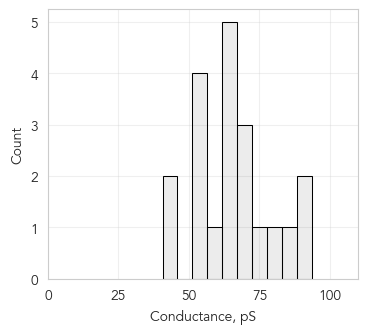

In [31]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 3.5))
ax = axs

final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance_results.csv")
    final_conductance.append(results.iloc[-1].Conductance)

ax.hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "vertical", facecolor = (0, 0, 0, 0.075), edgecolor = "black", linewidth = 0.75)
ax.set_xlabel(r"Conductance, pS")
ax.set_ylabel("Count")
ax.set_xlim(0, 110)
ax.set_xticks(range(0, 125, 25))
ax.grid(True, alpha = 0.3)

print(f"Mean conductance: {round(np.mean(np.array(final_conductance) * 1000_000))} pS")
print(f"STD: {round(np.std(np.array(final_conductance) * 1000_000))} pS")

In [32]:
colors = {
    "No TI": "tab:blue",
    "0 Hz TI": "tab:red",
    "5 Hz TI": "tab:orange",
    "130 Hz TI": "tab:green"
}

In [33]:
def pad_edges(data, pad_width):
    return np.pad(data, pad_width, mode="edge")

In [34]:
def smooth_data(data, window_size=10):
    dt = np.convolve(data, np.ones(window_size)/window_size, mode="valid")
    len_diff = len(data) - len(dt)
    
    return pad_edges(dt, int(len_diff / 2))

In [35]:
def plot_weights(weights, time, label, color, ax):
    mean = smooth_data(weights.mean(axis = 0), window_size = 1000)
    error = weights.std(axis = 0) / np.sqrt(weights.shape[0])
    error = error[:-1]

    ax.plot(
        time[:-1],
        mean,
        linewidth = 1,
        label = label,
        color = color
    )

    ax.fill_between(
        time[:-1], mean - error, mean + error,
        alpha = 0.15,
        color = color
    )

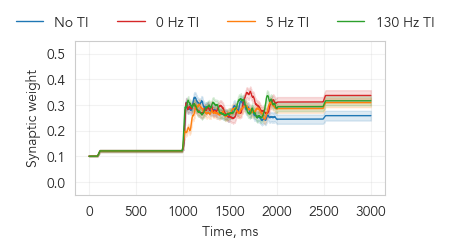

In [36]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (4, 2))
ax = axs

plot_weights(weights_no_ti, time_no_ti, label = "No TI", color = colors["No TI"], ax = ax)
plot_weights(weights_0, time_0, label = "0 Hz TI", color = colors["0 Hz TI"], ax = ax)
plot_weights(weights_5, time_5, label = "5 Hz TI", color = colors["5 Hz TI"], ax = ax)
plot_weights(weights_130, time_130, label = "130 Hz TI", color = colors["130 Hz TI"], ax = ax)

ax.set_ylim(-0.05, 0.55)
ax.set_ylabel("Synaptic weight")
ax.set_yticks(np.arange(0, 0.6, 0.1))

ax.set_xlabel("Time, ms")

ax.grid(alpha = 0.25)
fig.legend(loc = "upper center", ncol = 4, frameon = False, bbox_to_anchor = (0.5, 1.07))

plt.show()

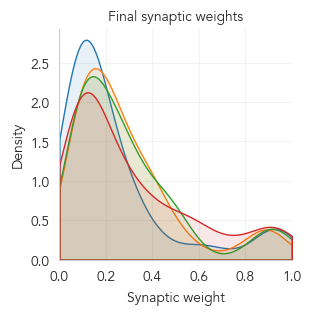

In [37]:
fig, axs = plt.subplots(nrows = 1, ncols = 1, figsize = (3, 3))
ax = axs

for condition in final_weights.keys():
    sns.kdeplot(
        final_weights[condition],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = condition,
        fill = True,
        alpha = 0.1
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Synaptic weight")

ax.grid(alpha = 0.25)
sns.despine(top = True, right = True)

ax.set_title("Final synaptic weights", fontsize = 10)

plt.show()

EPSP before: 2.12
STD: 2.35
EPSP after: 3.76
STD: 2.22


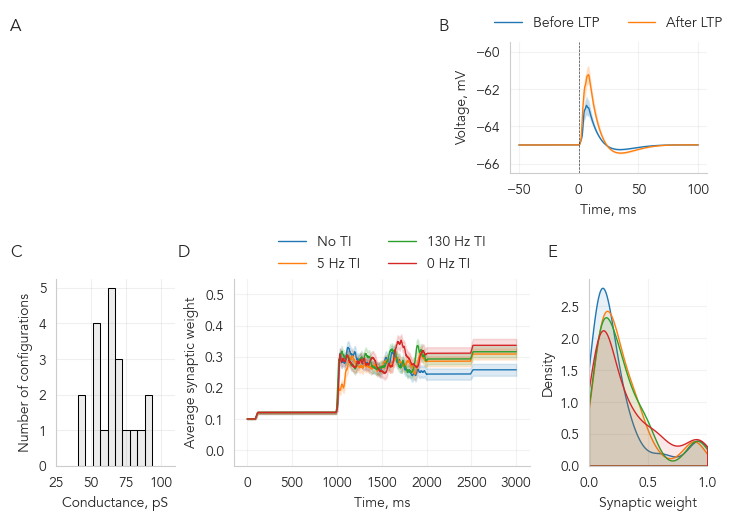

In [39]:
fig = plt.figure(figsize = (8.4, 5.5))

outer_gs = gridspec.GridSpec(3, 1, height_ratios = [0.7, 0.3, 1])

# A panel - neuron with synapses marked
# B panel - EPSP

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 2, subplot_spec = outer_gs[0], width_ratios = [2, 1])
ax = fig.add_subplot(inner_gs[0, 1])

epsp_before = []
epsp_after = []

time = []

for idx in idxs:
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/noTI_0.1/voltage.csv")

    time_epsp_before = np.logical_and(voltage.Time > test_stimulus_1 - time_before, voltage.Time < test_stimulus_1 + time_after)
    epsp_before_idx = np.array(voltage.Voltage[time_epsp_before].tolist())
    epsp_before.append(epsp_before_idx)

    time_epsp_after = np.logical_and(voltage.Time > test_stimulus_2 - time_before, voltage.Time < test_stimulus_2 + time_after)
    epsp_after_idx = np.array(voltage.Voltage[time_epsp_after].tolist())
    epsp_after.append(epsp_after_idx)

    time = np.array((voltage.Time[time_epsp_before] - test_stimulus_1).tolist())
    time, epsp_before_idx, epsp_after_idx = match_array_size(time, epsp_before_idx, epsp_after_idx)

epsp_before = np.array(epsp_before).T
epsp_after = np.array(epsp_after).T

time, epsp_before, epsp_after = match_array_size(time, epsp_before, epsp_after)

mean = epsp_before.mean(axis = 1)
error = epsp_before.std(axis = 1)  / np.sqrt(epsp_before.shape[1])

max_at = np.argmax(mean)
std = epsp_before.std(axis = 1)
print(f"EPSP before: {round(mean[max_at] - mean[0], 2)}")
print(f"STD: {round(std[max_at], 2)}")

plt.plot(
    time,
    mean,
    linewidth = 1,
    label = "Before LTP"
)
plt.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

mean = epsp_after.mean(axis = 1)
error = epsp_after.std(axis = 1) / np.sqrt(epsp_after.shape[1])

max_at = np.argmax(mean)
std = epsp_after.std(axis = 1)
print(f"EPSP after: {round(mean[max_at] - mean[0], 2)}")
print(f"STD: {round(std[max_at], 2)}")

ax.plot(
    time,
    mean,
    linewidth = 1,
    label = "After LTP"
)
ax.fill_between(
    time, mean - error, mean + error,
    alpha = 0.25
)

ax.set_xlabel("Time, ms", fontsize = 10)
ax.set_ylabel("Voltage, mV", fontsize = 10)
ax.set_ylim(-66.5, -59.5)
ax.axvline(0, linewidth = 0.5, linestyle = "--", color = "black", alpha = 0.75)
ax.grid(True, alpha = 0.25)

ax.legend(loc = "upper center", frameon = False, ncol = 2, bbox_to_anchor = (0.5, 1.3))

# C panel - distribution of conductances
# D panel - weight dynamics
# E panel - distribution of final weights (before test stimulus)

inner_gs = gridspec.GridSpecFromSubplotSpec(1, 4, subplot_spec = outer_gs[2], wspace = 0.5)

ax = fig.add_subplot(inner_gs[0, 0])

final_conductance = []
for idx in idxs:
    results = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance_results.csv")
    final_conductance.append(results.iloc[-1].Conductance)

ax.hist(np.array(final_conductance) * 1000_000, bins = 10, orientation = "vertical", facecolor = (0, 0, 0, 0.075), edgecolor = "black", linewidth = 0.75)
ax.set_xlabel(r"Conductance, pS")
ax.set_ylabel("Number of configurations")
ax.set_xlim(25, 110)
ax.set_xticks(range(25, 125, 25))
ax.grid(True, alpha = 0.3)

####

ax = fig.add_subplot(inner_gs[0, 1:3])

plot_weights(weights_no_ti, time_no_ti, label = "No TI", color = colors["No TI"], ax = ax)
plot_weights(weights_5, time_5, label = "5 Hz TI", color = colors["5 Hz TI"], ax = ax)
plot_weights(weights_130, time_130, label = "130 Hz TI", color = colors["130 Hz TI"], ax = ax)
plot_weights(weights_0, time_0, label = "0 Hz TI", color = colors["0 Hz TI"], ax = ax)

ax.set_ylim(-0.05, 0.55)
ax.set_ylabel("Average synaptic weight")
ax.set_yticks(np.arange(0, 0.6, 0.1))

ax.set_xlabel("Time, ms")

ax.grid(alpha = 0.25)

ax.legend(loc = "upper center", ncol = 2, frameon = False, bbox_to_anchor = (0.5, 1.3))

######

ax = fig.add_subplot(inner_gs[0, 3])

for condition in final_weights.keys():
    sns.kdeplot(
        final_weights[condition],
        bw_adjust = 1,
        ax = ax,
        clip = (0, 1),
        label = condition,
        fill = True,
        alpha = 0.1
    )

ax.set_xlim(0, 1)
ax.set_xlabel("Synaptic weight")

ax.grid(alpha = 0.25)
sns.despine(top = True, right = True)

fig.text(0.07, 0.9, "A", fontsize = 12)
fig.text(0.58, 0.9, "B", fontsize = 12)
fig.text(0.07, 0.49, "C", fontsize = 12)
fig.text(0.27, 0.49, "D", fontsize = 12)
fig.text(0.71, 0.49, "E", fontsize = 12)

plt.savefig("results_3.png", dpi = 500, bbox_inches = "tight")

# Supplementary

- Voltage traces for all synaptic configurations
- Weight dynamics for all synaptic configurations

- voltage for TI 5 Hz
- weight dynamics for TI 5 Hz

- voltage for TI 130 Hz
- weight dynamics for TI 130 Hz

- voltage for TI 0 Hz -- only carrier (same strength as for 130 Hz?)
- weight dynamics for TI 0 Hz -- only carrier (same strength as for 130 Hz?)

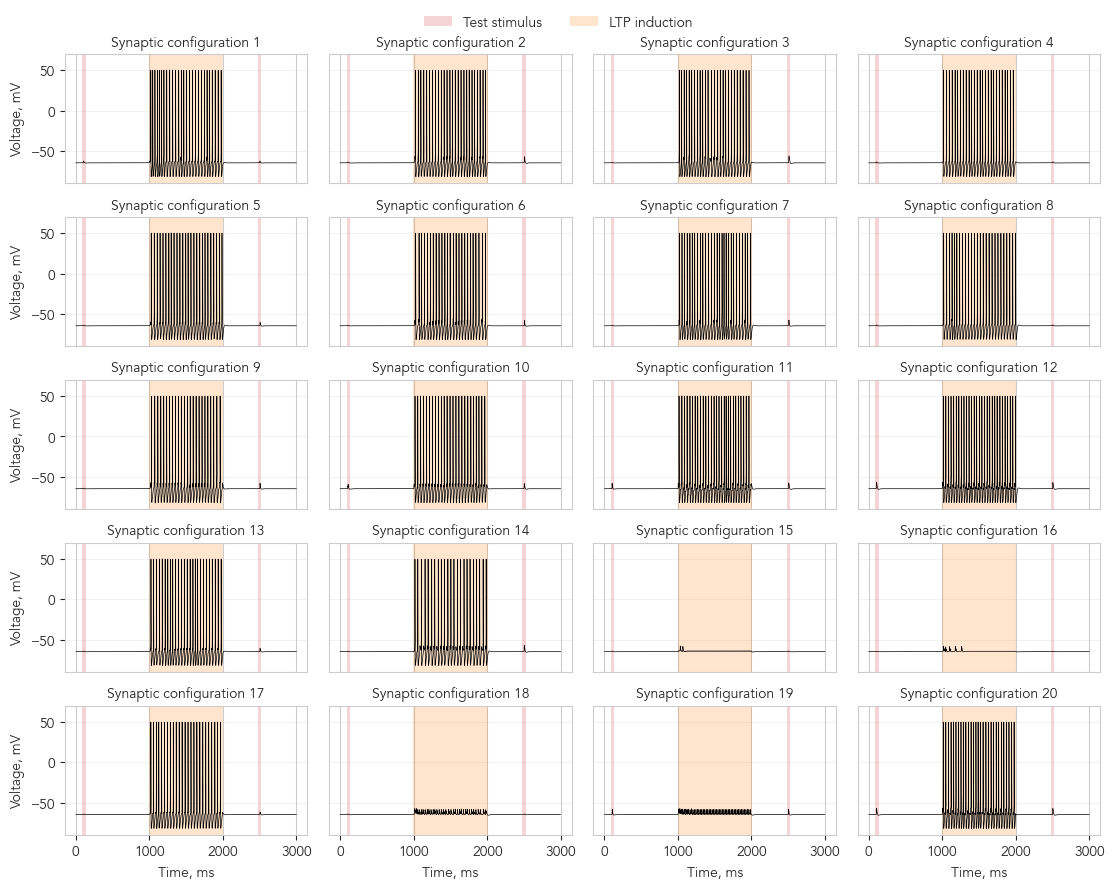

In [366]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/noTI_0.1/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    ax.set_ylim(-90, 70)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )
    
    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Voltage, mV")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_1.png", dpi = 500, bbox_inches = "tight")

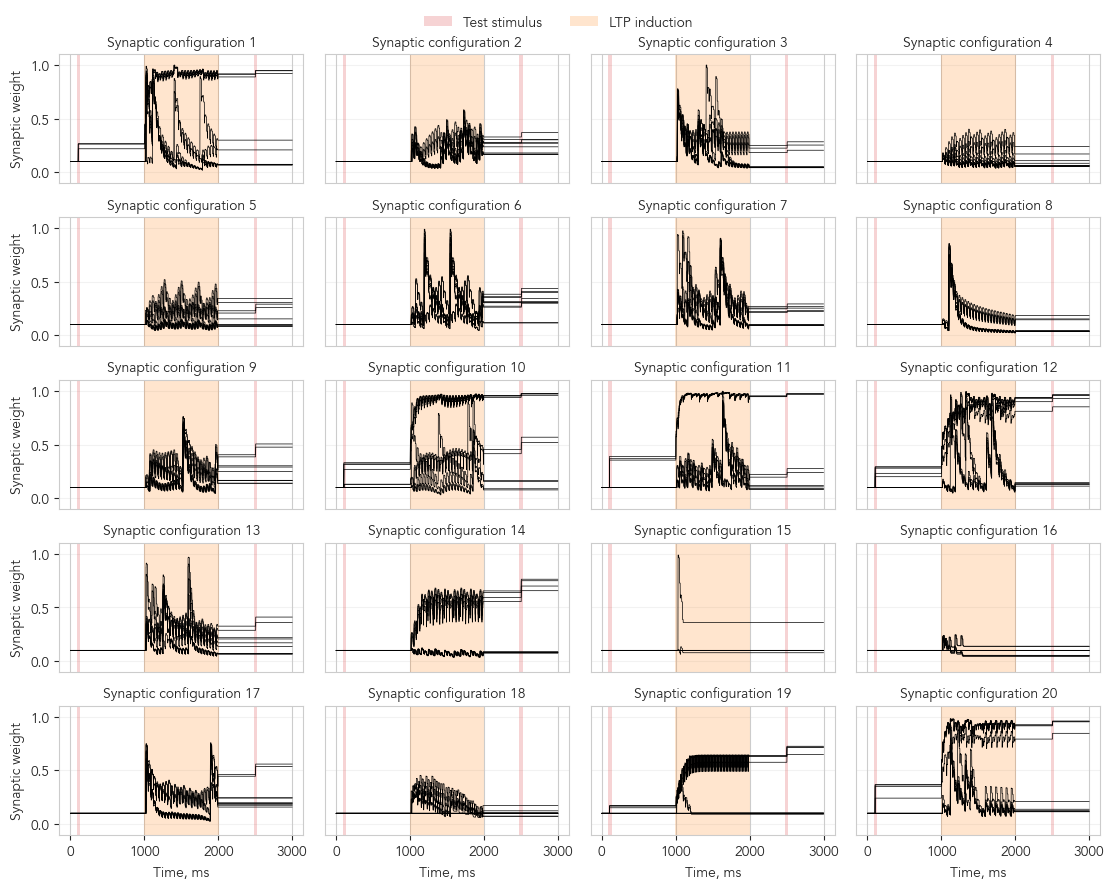

In [367]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    weights = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/noTI_0.1/synapse_weights.csv", index_col = 0)
    synapses = [f"Synapse{i}" for i in range(10)]

    for synapse in synapses:
        ax.plot(
            weights.Time,
            weights[synapse],
            linewidth = 0.5,
            color = "black"
        )

    ax.set_ylim(-0.1, 1.1)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Synaptic weight")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_2.png", dpi = 500, bbox_inches = "tight")

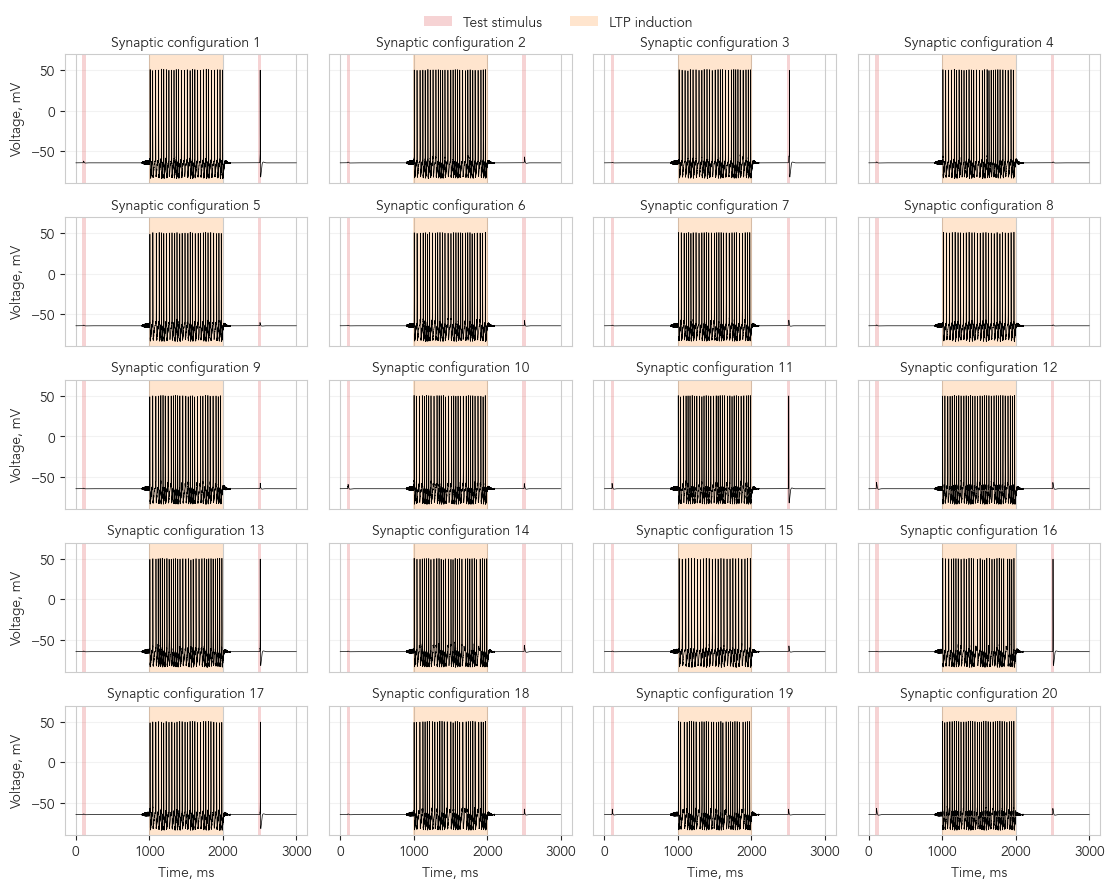

In [368]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/1000_5_0.9_0.1/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    ax.set_ylim(-90, 70)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Voltage, mV")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_3.png", dpi = 500, bbox_inches = "tight")

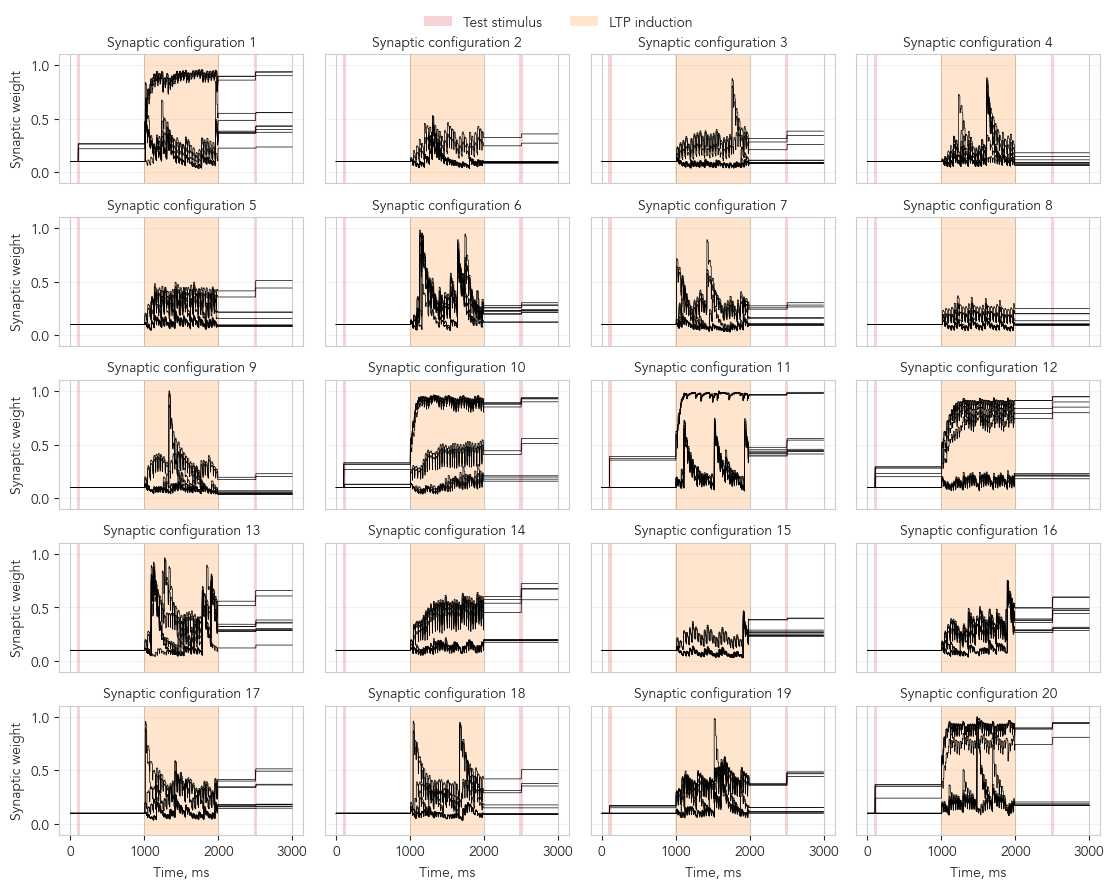

In [369]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    weights = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/1000_5_0.9_0.1/synapse_weights.csv", index_col = 0)
    synapses = [f"Synapse{i}" for i in range(10)]

    for synapse in synapses:
        ax.plot(
            weights.Time,
            weights[synapse],
            linewidth = 0.5,
            color = "black"
        )

    ax.set_ylim(-0.1, 1.1)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Synaptic weight")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_4.png", dpi = 500, bbox_inches = "tight")

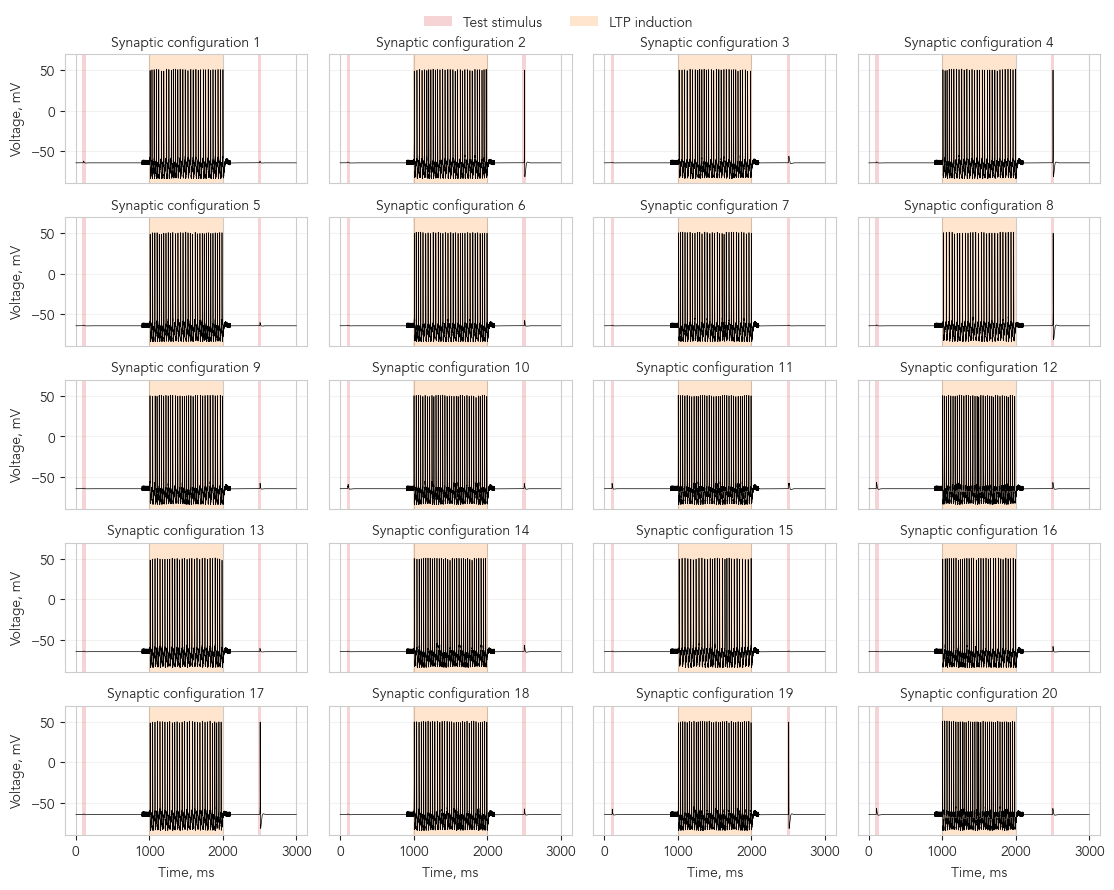

In [370]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/1000_130_0.9_0.1/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    ax.set_ylim(-90, 70)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Voltage, mV")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_5.png", dpi = 500, bbox_inches = "tight")

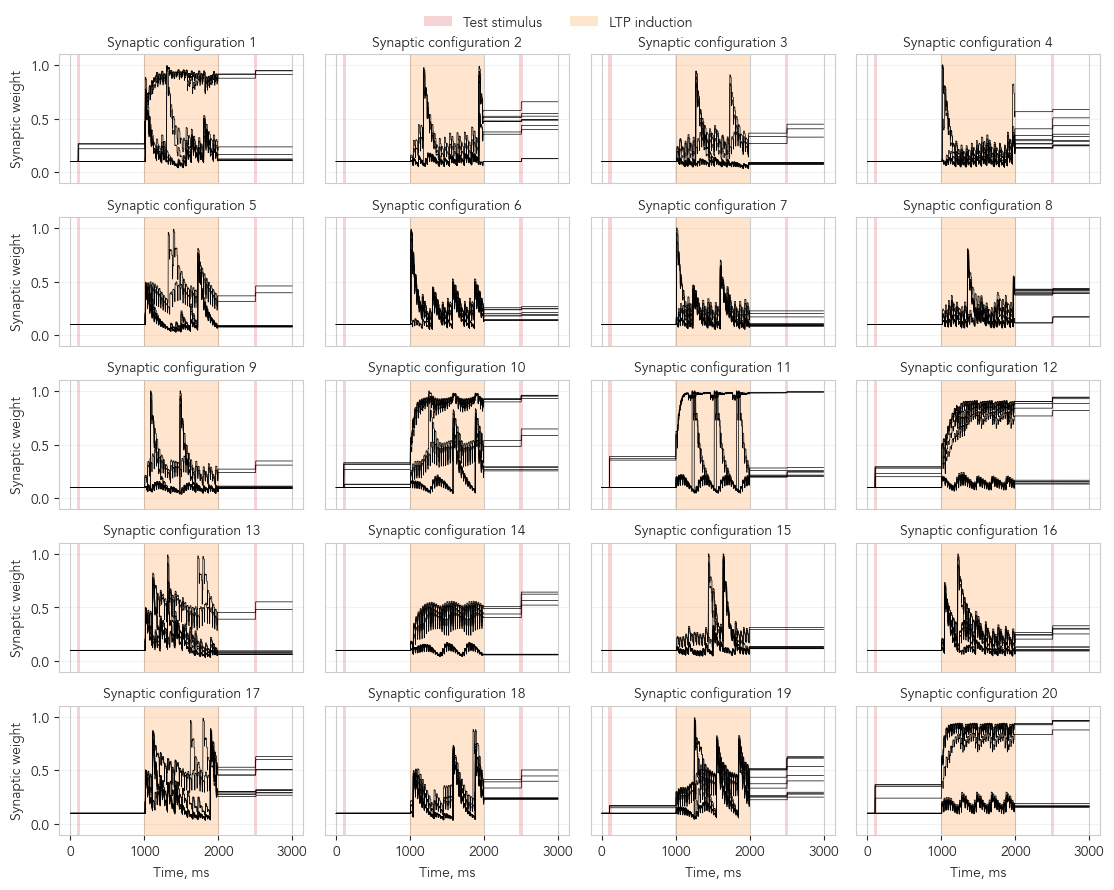

In [371]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    weights = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/1000_130_0.9_0.1/synapse_weights.csv", index_col = 0)
    synapses = [f"Synapse{i}" for i in range(10)]

    for synapse in synapses:
        ax.plot(
            weights.Time,
            weights[synapse],
            linewidth = 0.5,
            color = "black"
        )

    ax.set_ylim(-0.1, 1.1)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Synaptic weight")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_6.png", dpi = 500, bbox_inches = "tight")

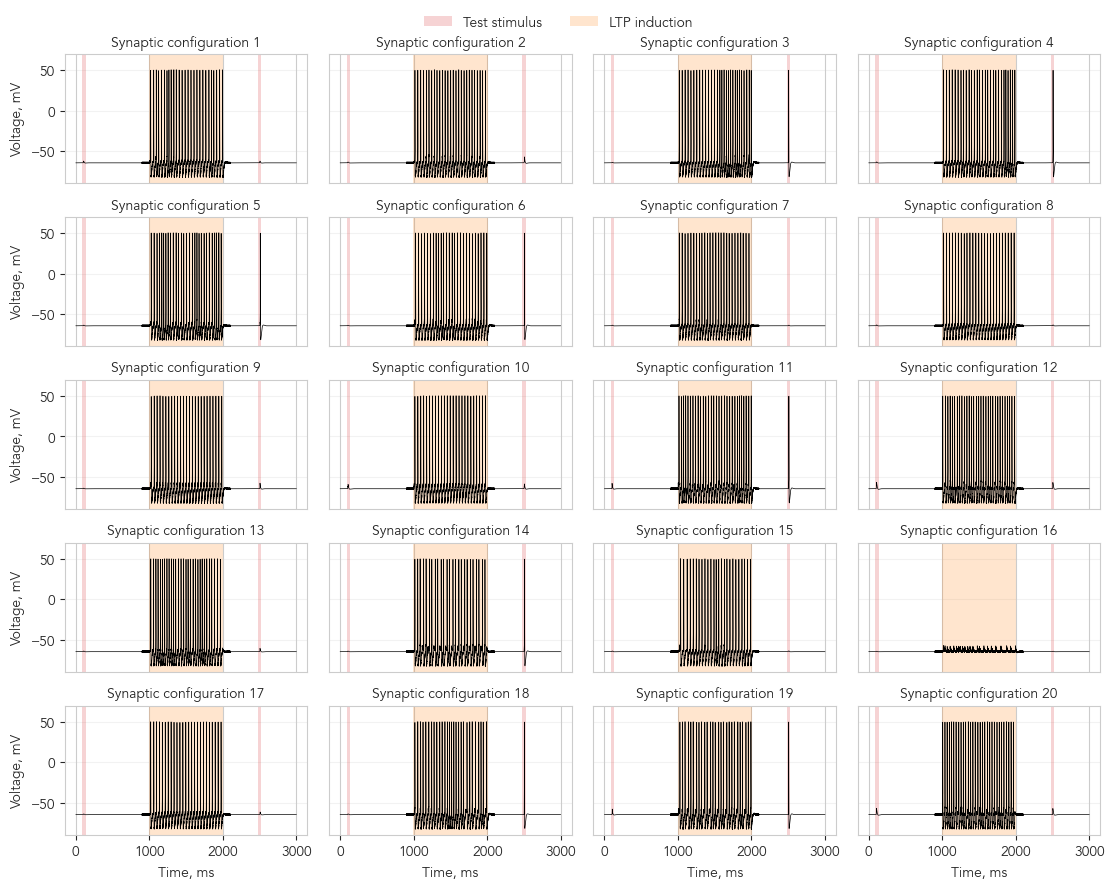

In [372]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    voltage = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/1000_0_0.32_0.1/voltage.csv")

    ax.plot(
        voltage.Time,
        voltage.Voltage,
        linewidth = 0.5,
        color = "black"
    )

    ax.set_ylim(-90, 70)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Voltage, mV")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_7.png", dpi = 500, bbox_inches = "tight")

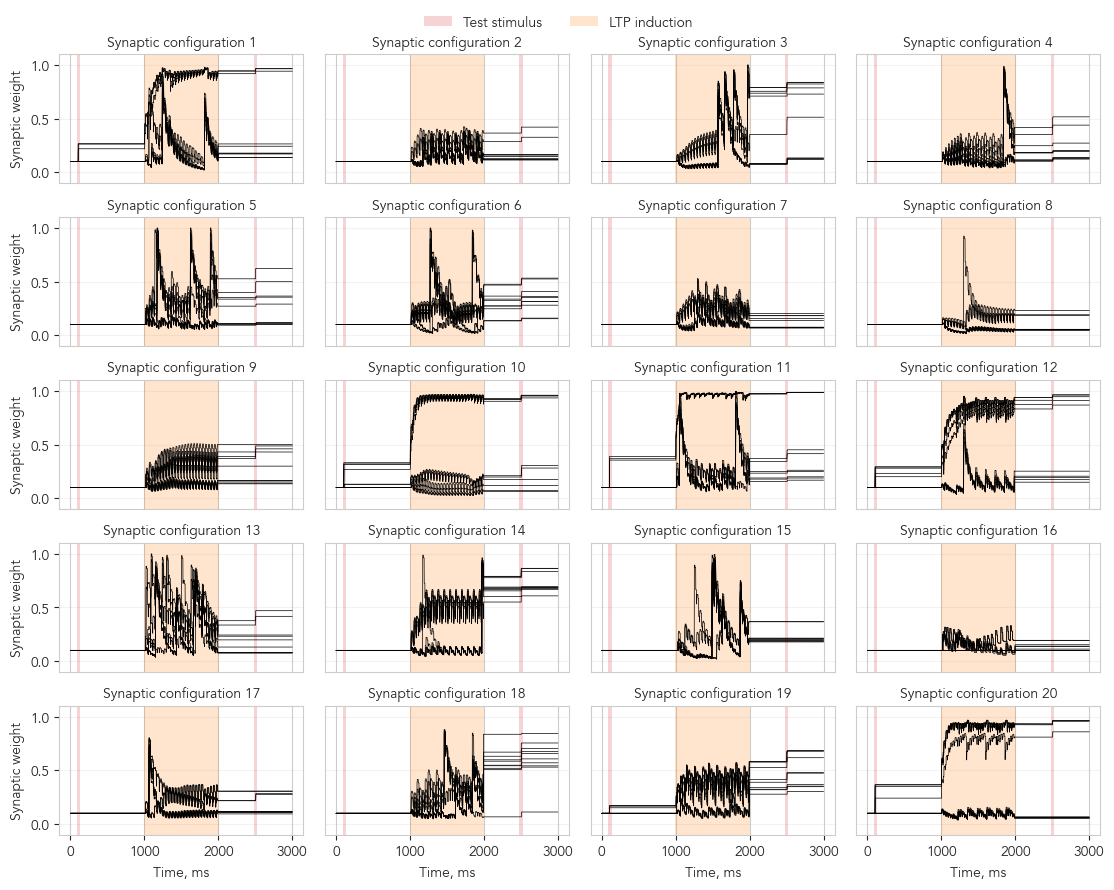

In [373]:
fig, axs = plt.subplots(nrows = int(len(idxs) / 4), ncols = 4, figsize = (fig_width, int(len(idxs) / 4) * 1.75), sharey = True, sharex = True)

for idx, ax in zip(idxs, axs.flatten()):
    weights = pd.read_csv(f"output/temporal-interference-1/{idx}/subthreshold_conductance/ltp/1000_0_0.32_0.1/synapse_weights.csv", index_col = 0)
    synapses = [f"Synapse{i}" for i in range(10)]

    for synapse in synapses:
        ax.plot(
            weights.Time,
            weights[synapse],
            linewidth = 0.5,
            color = "black"
        )

    ax.set_ylim(-0.1, 1.1)

    ax.set_title(f"Synaptic configuration {idx + 1}", fontsize = 10)

    label_test = "Test stimulus" if idx == 0 else ""
    label_ltp = "LTP induction" if idx == 0 else ""

    ax.axvspan(
        test_stimulus_1 - 10,
        test_stimulus_1 + 35,
        alpha = 0.2,
        color = "tab:red",
        label = label_test,
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        test_stimulus_2 - 20,
        test_stimulus_2 + 25,
        alpha = 0.2,
        color = "tab:red",
        zorder = 1,
        linewidth = 0
    )

    ax.axvspan(
        ltp_start - 5,
        ltp_start + ltp_duration + 5,
        alpha = 0.2,
        color = "tab:orange",
        label = label_ltp,
        zorder = 1,
        linewidth = 0
    )

    ax.tick_params(left = False, labelleft = False)
    ax.tick_params(bottom = False, labelbottom = False)

    ax.grid(True, alpha = 0.25, axis = "y")

for ax in axs:
    ax[0].set_ylabel("Synaptic weight")
    ax[0].tick_params(left = True, labelleft = True)

for i in range(len(axs[0])):
    axs[-1][i].set_xlabel("Time, ms")
    axs[-1][i].tick_params(bottom = True, labelbottom = True)

fig.legend(loc = "upper center", bbox_to_anchor = (0.5, 1.02), frameon = False, ncol = 2)
fig.tight_layout()

plt.savefig("supplementary_results_2_8.png", dpi = 500, bbox_inches = "tight")